# Spatially smoothed PCA global component

This notebook performs a brief visual sanity check of the spatially smoothed PCA global-component implementation.

We load an example SNIRF dataset, compute the global component, and compare:

1. raw data
2. spatially smoothed PCA global component
3. raw data minus global component

Note: this example dataset is channel-space data, so the spatial smoothing kernel is built from channel midpoint coordinates rather than vertex coordinates.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

import cedalion
import cedalion.data
import cedalion.io
import cedalion.nirs
import cedalion.dataclasses as cdc
import cedalion.xrutils as xrutils

from cedalion.sigproc.physio import (
    get_spatial_smoothing_kernel,
    compute_Hglobal_from_PCA,
)

In [6]:
rec = cedalion.data.get_snirf_test_data()
rec = rec[0]
rec

<Recording |  timeseries: ['amp'],  masks: [],  stim: [],  aux_ts: ['accelerometer_1_x', 'accelerometer_1_y', 'accelerometer_1_z', 'gyroscope_1_x', 'gyroscope_1_y', 'gyroscope_1_z'],  aux_obj: []>

In [7]:
ts = rec["amp"]
ts

Magnitude,[[[0.01761355 0.017606669999999998 0.017581649999999997 ... 0.033620899999999995 0.03357263 0.03365514] [0.35101631 0.35086065 0.3509154 ... 0.72202989 0.7214472399999999 0.72074867]] [[0.00106896 0.00104624 0.00104647 ... 0.0033191500000000003 0.0033195900000000003 0.0033532500000000003] [0.01886084 0.01888285 0.01886284 ... 0.07176738 0.07178378 0.07178838]] [[0.00101412 0.00100238 0.0009993699999999999 ... 0.00172957 0.00175206 0.00174381] [0.0279039 0.027883739999999997 0.027909859999999998 ... 0.03793812 0.03795346 0.037966]] ... [[0.09820013 0.09809280999999999 0.09770253 ... 0.02333816 0.02333474 0.02335939] [1.7264376099999998 1.7256885899999999 1.72406511 ... 0.31087457 0.31094666 0.31093098]] [[0.00358964 0.00358589 0.00368625 ... 0.02973222 0.0297537 0.029665530000000002] [0.04759784 0.04769824 0.047756360000000005 ... 0.34196123 0.34198317 0.34200283]] [[0.00379172 0.00384169 0.0038755 ... 0.0056179 0.00569871 0.0056428] [0.04745179 0.04748906 0.047548440000000004 ... 0.07256665 0.07263192 0.07271912]]]
Units,dimensionless


In [8]:
spatial_dim = cdc.get_spatial_dimension(ts)
spectral_dim = xrutils.other_dim(ts, spatial_dim, "time")

spatial_dim, spectral_dim

('channel', 'wavelength')

In [9]:
geo3d = rec.geo3d

channel_pos = (
    geo3d.loc[ts.source].pint.dequantify()
    + geo3d.loc[ts.detector].pint.dequantify()
) / 2

vertices = channel_pos.values

vertices.shape

(46, 3)

In [10]:
W = get_spatial_smoothing_kernel(vertices, sigma_mm=80.0)

W.shape, W.min(), W.max()

((46, 46), np.float32(9.057308e-05), np.float32(0.112760365))

In [11]:
global_field = compute_Hglobal_from_PCA(
    ts,
    smoothing_kernel=W,
    spatial_dim=spatial_dim,
    spectral_dim=spectral_dim,
)

global_field

Magnitude,[[[0.017299022525548935 0.017293967306613922 0.01730610430240631 ... 0.031584396958351135 0.030703550204634666 0.02994934469461441] [0.28113073110580444 0.2810857594013214 0.2810923159122467 ... 0.6025880575180054 0.6008684635162354 0.5991976261138916]] [[0.017498541623353958 0.017495274543762207 0.01750911958515644 ... 0.03183902055025101 0.030980028212070465 0.03024308569729328] [0.2820928990840912 0.28206485509872437 0.2820722460746765 ... 0.6066693067550659 0.6049603819847107 0.6032226085662842]] [[0.0170292928814888 0.01702248491346836 0.01703481748700142 ... 0.03207029774785042 0.03132084012031555 0.03068527951836586] [0.27928590774536133 0.2792447507381439 0.2792516350746155 ... 0.624544620513916 0.6231327056884766 0.6217437982559204]] ... [[0.01987582817673683 0.01984841376543045 0.01982644386589527 ... 0.010439230129122734 0.010412772186100483 0.010390860959887505] [0.3215143382549286 0.32144680619239807 0.3213362693786621 ... 0.1450023055076599 0.14497877657413483 0.14495693147182465]] [[0.017765408381819725 0.017750298604369164 0.017725732177495956 ... 0.012961693108081818 0.0129398163408041 0.012936761602759361] [0.2914082705974579 0.29132071137428284 0.2912972867488861 ... 0.18225519359111786 0.1822347640991211 0.18222108483314514]] [[0.016799302771687508 0.016786200925707817 0.016762465238571167 ... 0.013155484572052956 0.013138089329004288 0.013134617358446121] [0.27737680077552795 0.2772798538208008 0.2773134112358093 ... 0.18637681007385254 0.18635593354701996 0.1863451898097992]]]
Units,dimensionless


In [12]:
residual = ts - global_field
residual

Magnitude,[[[0.0003145274744510637 0.00031270269338607576 0.00027554569759368625 ... 0.00203650304164886 0.0028690797953653327 0.0037057953053855897] [0.06988557889419555 0.06977489059867859 0.06982308408775328 ... 0.11944183248199458 0.12057877648376458 0.12155104388610838]] [[-0.016429581623353957 -0.016449034543762207 -0.01646264958515644 ... -0.028519870550251007 -0.027660438212070464 -0.02688983569729328] [-0.2632320590840912 -0.26318200509872436 -0.2632094060746765 ... -0.5349019267550659 -0.5331766019847107 -0.5314342285662842]] [[-0.0160151728814888 -0.01602010491346836 -0.01603544748700142 ... -0.03034072774785042 -0.029568780120315552 -0.02894146951836586] [-0.25138200774536135 -0.25136101073814393 -0.25134177507461547 ... -0.586606500513916 -0.5851792456884766 -0.5837777982559205]] ... [[0.07832430182326316 0.07824439623456954 0.07787608613410472 ... 0.012898929870877266 0.012921967813899517 0.012968529040112496] [1.4049232717450713 1.4042417838076018 1.4027288406213378 ... 0.1658722644923401 0.16596788342586516 0.16597404852817538]] [[-0.014175768381819725 -0.014164408604369164 -0.014039482177495956 ... 0.016770526891918183 0.0168138836591959 0.01672876839724064] [-0.24381043059745788 -0.24362247137428283 -0.2435409267488861 ... 0.15970603640888215 0.1597484059008789 0.15978174516685484]] [[-0.013007582771687507 -0.012944510925707817 -0.012886965238571167 ... -0.007537584572052955 -0.007439379329004288 -0.007491817358446121] [-0.22992501077552796 -0.22979079382080078 -0.22976497123580933 ... -0.11381016007385254 -0.11372401354701996 -0.1136260698097992]]]
Units,dimensionless


In [13]:
spectral_value = ts[spectral_dim].values[0]

raw_2d = ts.sel({spectral_dim: spectral_value}).pint.dequantify()
global_2d = global_field.sel({spectral_dim: spectral_value}).pint.dequantify()
residual_2d = residual.sel({spectral_dim: spectral_value}).pint.dequantify()

n_show = min(10, ts.sizes[spatial_dim])

spectral_value, n_show

(np.float64(760.0), 10)

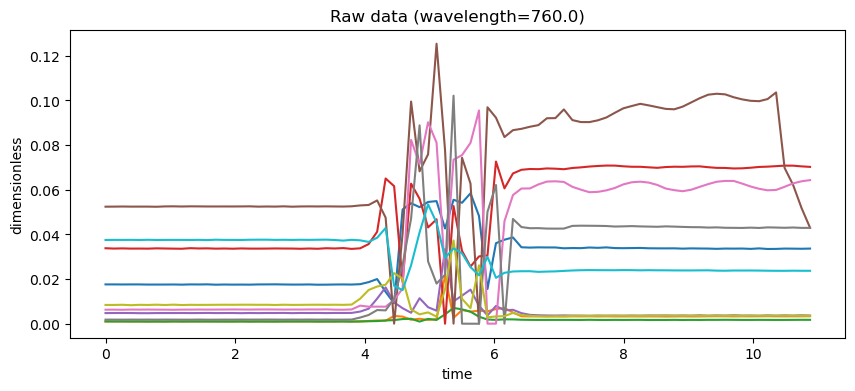

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(
    raw_2d.time,
    raw_2d.isel({spatial_dim: slice(0, n_show)}).transpose("time", spatial_dim),
)
plt.title(f"Raw data ({spectral_dim}={spectral_value})")
plt.xlabel("time")
plt.ylabel(str(ts.pint.units))
plt.show()

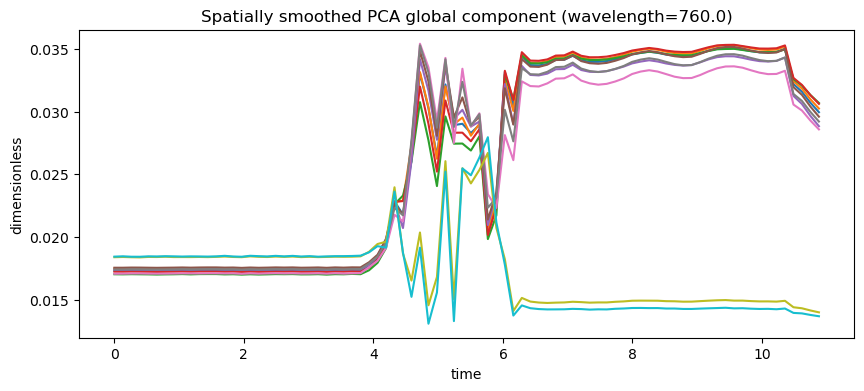

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(
    global_2d.time,
    global_2d.isel({spatial_dim: slice(0, n_show)}).transpose("time", spatial_dim),
)
plt.title(f"Spatially smoothed PCA global component ({spectral_dim}={spectral_value})")
plt.xlabel("time")
plt.ylabel(str(ts.pint.units))
plt.show()

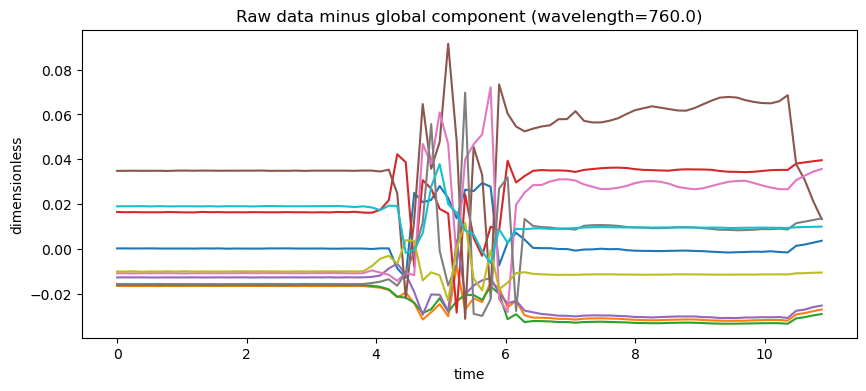

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(
    residual_2d.time,
    residual_2d.isel({spatial_dim: slice(0, n_show)}).transpose("time", spatial_dim),
)
plt.title(f"Raw data minus global component ({spectral_dim}={spectral_value})")
plt.xlabel("time")
plt.ylabel(str(ts.pint.units))
plt.show()

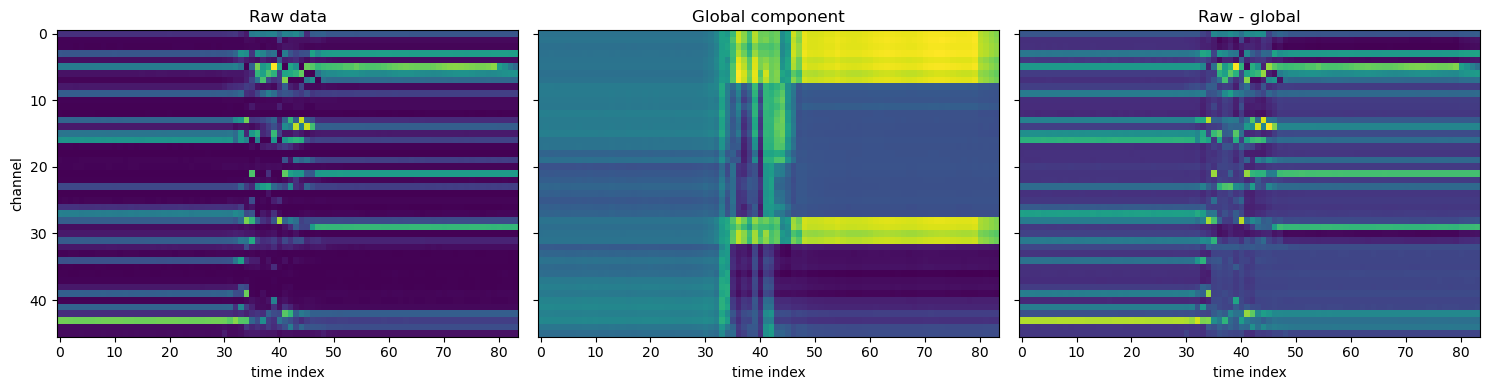

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

raw_plot = raw_2d.transpose(spatial_dim, "time")
global_plot = global_2d.transpose(spatial_dim, "time")
residual_plot = residual_2d.transpose(spatial_dim, "time")

axes[0].imshow(raw_plot, aspect="auto")
axes[0].set_title("Raw data")
axes[0].set_xlabel("time index")
axes[0].set_ylabel(spatial_dim)

axes[1].imshow(global_plot, aspect="auto")
axes[1].set_title("Global component")
axes[1].set_xlabel("time index")

axes[2].imshow(residual_plot, aspect="auto")
axes[2].set_title("Raw - global")
axes[2].set_xlabel("time index")

plt.tight_layout()
plt.show()